# Домашнее задание. Основы машинного обучения

Темы задания:

1. обучение с учителем и без, регрессия и классификация;
2. обучающая, валидационная и тестовая выборки;
3. переобучение и недообучение, компромисс смещения и разброса;
4. регуляризация L1 и L2;
5. кросс-валидация: k-fold, стратифицированная, по времени, групповая.

**Как работать с ноутбуком**

- Ячейки с графиками уже написаны: просто запусти их и посмотри на картинки.
- Где написано **«Твой ответ»**, ответь текстом, 1–3 предложения. Своими словами, без копирования из конспекта.
- Где в ячейке с кодом есть комментарии, напиши код под ними. Нужны только numpy и обычный Python.

## Подготовка

In [1]:
# Просто запусти эту ячейку
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (12, 3.6)

## Часть 1. Обучение с учителем и без, регрессия и классификация

### 1.1. Теоретические вопросы

1. Что такое объект, признаки и целевая переменная? Приведи пример для задачи «предсказать цену квартиры».
2. Чем обучение с учителем отличается от обучения без учителя?
3. Приведи по два примера задач обучения с учителем и без учителя.
4. Чем регрессия отличается от классификации?
5. Логистическая регрессия — это модель регрессии или классификации? Почему?

**Твой ответ:**

_..._

### 1.2. Какая это задача?

Запусти ячейку и посмотри на четыре графика. Каждый показывает обучающие данные для какой-то задачи. Для каждого графика напиши:

- это обучение **с учителем** или **без учителя**;
- если с учителем — это **регрессия** или **классификация**.

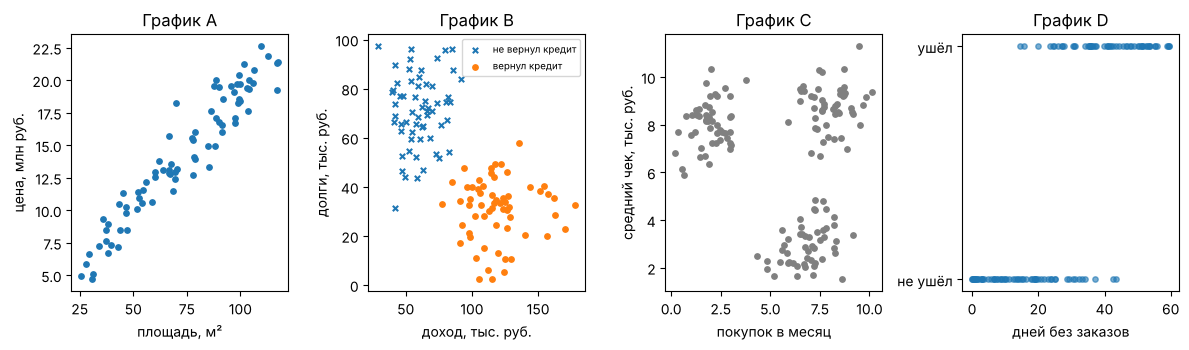

In [2]:
fig, ax = plt.subplots(1, 4)

# График A
area = rng.uniform(25, 120, 80)
price = 2 + 0.17 * area + rng.normal(0, 1.5, 80)
ax[0].scatter(area, price, s=15)
ax[0].set_xlabel("площадь, м²"); ax[0].set_ylabel("цена, млн руб."); ax[0].set_title("График A")

# График B
income = np.r_[rng.normal(60, 15, 60), rng.normal(120, 20, 60)]
debt = np.r_[rng.normal(70, 15, 60), rng.normal(30, 12, 60)]
cls = np.r_[np.zeros(60), np.ones(60)]
ax[1].scatter(income[cls == 0], debt[cls == 0], s=15, marker="x", label="не вернул кредит")
ax[1].scatter(income[cls == 1], debt[cls == 1], s=15, marker="o", label="вернул кредит")
ax[1].set_xlabel("доход, тыс. руб."); ax[1].set_ylabel("долги, тыс. руб."); ax[1].set_title("График B")
ax[1].legend(fontsize=7)

# График C
centers = [(2, 8), (7, 3), (8, 9)]
pts = np.vstack([rng.normal(c, 0.9, size=(50, 2)) for c in centers])
ax[2].scatter(pts[:, 0], pts[:, 1], s=15, color="gray")
ax[2].set_xlabel("покупок в месяц"); ax[2].set_ylabel("средний чек, тыс. руб."); ax[2].set_title("График C")

# График D
minutes = rng.uniform(0, 60, 120)
churned = (minutes + rng.normal(0, 10, 120) > 30).astype(int)
ax[3].scatter(minutes, churned, s=15, alpha=0.6)
ax[3].set_yticks([0, 1]); ax[3].set_yticklabels(["не ушёл", "ушёл"])
ax[3].set_xlabel("дней без заказов"); ax[3].set_title("График D")

plt.tight_layout(); plt.show()

**Твой ответ:**

_..._

### 1.3. Корреляция

Корреляция показывает, насколько сильно два признака связаны **линейно**: когда растёт один, растёт (или падает) ли другой примерно по прямой. Посмотри на графики и для каждого напиши:

- сильная корреляция или её почти нет;
- если сильная — положительная (оба растут вместе) или отрицательная (один растёт, другой падает).

Отдельно подумай про график 4: есть ли там линейная корреляция и есть ли **зависимость**?

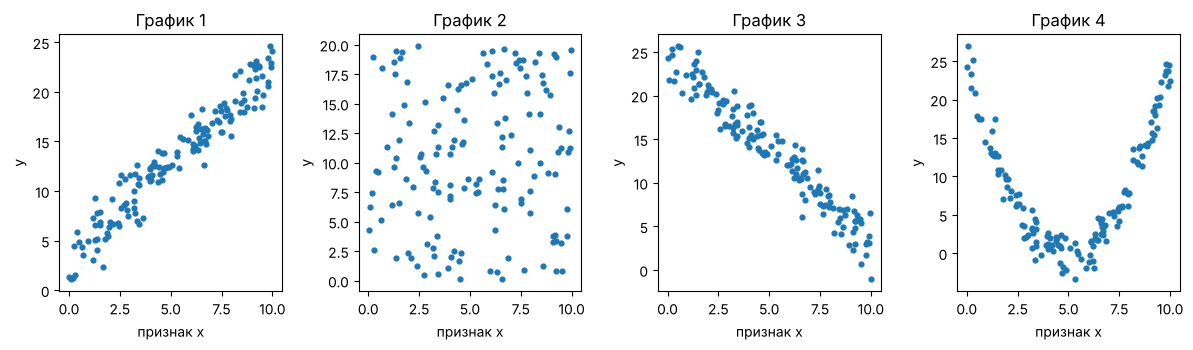

In [3]:
n = 150
x = rng.uniform(0, 10, n)

y1 = 3 + 2.0 * x + rng.normal(0, 1.5, n)           # график 1
y2 = rng.uniform(0, 20, n)                          # график 2
y3 = 25 - 2.2 * x + rng.normal(0, 1.5, n)           # график 3
y4 = (x - 5) ** 2 + rng.normal(0, 1.5, n)           # график 4

fig, ax = plt.subplots(1, 4)
for i, (yy, title) in enumerate([(y1, "График 1"), (y2, "График 2"), (y3, "График 3"), (y4, "График 4")]):
    ax[i].scatter(x, yy, s=12)
    ax[i].set_title(title); ax[i].set_xlabel("признак x"); ax[i].set_ylabel("y")
plt.tight_layout(); plt.show()

**Твой ответ:**

_..._

In [4]:
# Проверь себя: посчитай коэффициент корреляции для каждого графика
# Подсказка: np.corrcoef(x, y1)[0, 1] — число от -1 до 1
# Совпало с тем, что ты увидел на графиках?

### 1.4. Считаем по формуле линейной регрессии

Линейная регрессия предсказывает ответ как взвешенную сумму признаков:

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_3$$

Модель для цены квартиры уже обучена, её веса:

| | вес | признак |
|---|---|---|
| $w_0$ | 1.5 | свободный член |
| $w_1$ | 0.16 | площадь, м² |
| $w_2$ | −0.6 | расстояние до метро, км |
| $w_3$ | 0.05 | этаж |

Цена получается в млн руб.

**Задание.**

1. Посчитай на бумаге предсказание для квартиры: 50 м², 2 км до метро, 10-й этаж.
2. Посчитай в коде предсказания для трёх квартир из таблицы ниже.
3. Посчитай ошибку для каждой квартиры, а затем MAE и RMSE.

| квартира | площадь | до метро | этаж | настоящая цена |
|---|---|---|---|---|
| 1 | 50 | 2 | 10 | 9.0 |
| 2 | 35 | 0.5 | 3 | 6.8 |
| 3 | 80 | 4 | 15 | 12.5 |

**Твой ответ:**

_..._

In [5]:
# Запиши веса: w0, w1, w2, w3
# Запиши признаки трёх квартир в массивы area, metro, floor и настоящие цены в массив price
# Посчитай предсказания: y_pred = w0 + w1 * area + w2 * metro + w3 * floor
# Посчитай ошибки: error = price - y_pred
# MAE = среднее модулей ошибок: np.abs(error).mean()
# RMSE = корень из среднего квадратов ошибок: np.sqrt((error ** 2).mean())
# Выведи y_pred, error, MAE и RMSE

**Вопросы:** что означает вес −0.6 у расстояния до метро? Почему RMSE получилась чуть больше MAE?

**Твой ответ:**

_..._

## Часть 2. Обучающая, валидационная и тестовая выборки

### 2.1. Теоретические вопросы

1. Зачем делить данные на выборки? Почему нельзя проверять модель на тех же данных, на которых она училась?
2. Для чего нужна каждая из трёх выборок: обучающая, валидационная, тестовая?
3. Зачем нужна тестовая выборка, если уже есть валидационная? Что за «золотое правило» теста?
4. Что такое стратификация и когда она нужна?
5. Почему для задачи «предсказать продажи на следующую неделю» нельзя делить данные случайно?

**Твой ответ:**

_..._

### 2.2. Простые задачи

1. В таблице 10 000 строк. Сколько строк будет в каждой выборке при пропорциях 60/20/20? А при 70/15/15?
2. Среди 10 000 клиентов ушли 300. Какая доля ушедших во всех данных? Сколько ушедших должно оказаться в тестовой выборке из 2 000 строк при стратифицированном разбиении?
3. Есть 12 месяцев данных о продажах (январь–декабрь). Раздели их на обучение, валидацию и тест так, чтобы это было правильно для прогноза.

In [6]:
# Посчитай размеры выборок для 60/20/20 и 70/15/15
# Посчитай долю ушедших клиентов и ожидаемое число ушедших в тесте из 2 000 строк

**Твой ответ:**

_..._

## Часть 3. Переобучение и недообучение, смещение и разброс

### 3.1. Теоретические вопросы

1. Что такое недообучение и переобучение? Приведи аналогию со студентом на экзамене.
2. Как по ошибке на обучении и на валидации понять, что модель переобучилась?
3. Назови два способа бороться с переобучением и два — с недообучением.
4. Что такое смещение (bias) и разброс (variance)? Какой из них высокий при переобучении?
5. В чём компромисс смещения и разброса?

**Твой ответ:**

_..._

### 3.2. Как обучилась модель?

На каждом графике одни и те же обучающие точки (чёрные) и кривая, которую нарисовала обученная модель. Для каждого графика напиши: модель **недообучилась**, обучилась **хорошо** или **переобучилась**. Объясни, по каким признакам ты это понял.

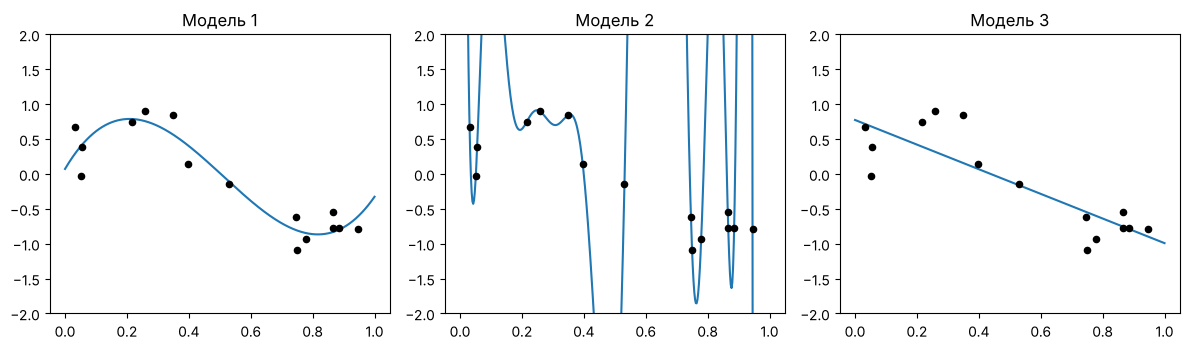

In [7]:
import warnings
warnings.filterwarnings("ignore")

x_tr = np.sort(rng.uniform(0, 1, 15))
y_tr = np.sin(2 * np.pi * x_tr) + rng.normal(0, 0.2, 15)
x_grid = np.linspace(0, 1, 400)

fig, ax = plt.subplots(1, 3)
for i, (deg, title) in enumerate([(3, "Модель 1"), (14, "Модель 2"), (1, "Модель 3")]):
    coef = np.polyfit(x_tr, y_tr, deg)
    ax[i].scatter(x_tr, y_tr, color="black", s=20, zorder=3)
    ax[i].plot(x_grid, np.polyval(coef, x_grid))
    ax[i].set_ylim(-2, 2); ax[i].set_title(title)
plt.tight_layout(); plt.show()

**Твой ответ:**

_..._

### 3.3. Диагноз по ошибкам

Четыре модели предсказывают время доставки. В таблице их ошибка (MAE в минутах) на обучающей и на валидационной выборке. Для каждой модели поставь диагноз: недообучение, переобучение, всё хорошо или подозрение на утечку данных.

| модель | ошибка на обучении | ошибка на валидации |
|---|---|---|
| A | 12.1 | 12.4 |
| B | 1.2 | 9.8 |
| C | 4.9 | 5.3 |
| D | 0.1 | 0.1 |

**Твой ответ:**

_..._

## Часть 4. Регуляризация L1 и L2

### 4.1. Теоретические вопросы

1. Зачем нужна регуляризация? Какую проблему она решает?
2. Запиши, из чего состоит функция потерь с регуляризацией. Что такое λ?
3. Что будет при λ = 0 и при очень большом λ?
4. Чем штраф L1 отличается от штрафа L2? Какой из них обнуляет веса?
5. Зачем перед регуляризацией масштабируют признаки?
6. В `LogisticRegression` есть параметр C. Как он связан с силой регуляризации?

**Твой ответ:**

_..._

### 4.2. Считаем штрафы

У модели четыре веса: $w = (3,\ -0.5,\ 0,\ 2)$. Свободный член $w_0$ не штрафуют.

1. Посчитай штраф L1: $|w_1| + |w_2| + |w_3| + |w_4|$.
2. Посчитай штраф L2: $w_1^2 + w_2^2 + w_3^2 + w_4^2$.
3. Ошибка модели на данных равна 10. Посчитай функцию потерь с L2-регуляризацией для λ = 0, 0.1 и 1.
4. Какой вес сильнее всего увеличивает штраф L2? Почему штраф L2 почти не замечает вес −0.5?

In [8]:
# Создай массив весов w = np.array([3, -0.5, 0, 2])
# Посчитай штраф L1 через np.abs(w).sum() и штраф L2 через (w ** 2).sum()
# Для каждого λ из [0, 0.1, 1] посчитай loss = 10 + λ * штраф L2 и выведи

**Твой ответ:**

_..._

## Часть 5. Кросс-валидация

### 5.1. Теоретические вопросы

1. Зачем нужна кросс-валидация, если можно один раз разделить данные на обучение и валидацию?
2. Как устроен k-fold? Сколько раз обучается модель при k = 5?
3. Чем стратифицированный k-fold отличается от обычного и когда он нужен?
4. Почему для временных данных нельзя использовать обычный k-fold? Как устроен TimeSeriesSplit?
5. Что такое групповая кросс-валидация? Приведи пример, где она нужна.

**Твой ответ:**

_..._

### 5.2. Считаем результат кросс-валидации

Две модели проверили 5-fold кросс-валидацией, метрика ROC-AUC (чем больше, тем лучше):

- модель А: 0.81, 0.80, 0.82, 0.81, 0.82
- модель Б: 0.86, 0.76, 0.84, 0.78, 0.83

1. Посчитай среднее и стандартное отклонение для каждой модели.
2. Какая модель стабильнее? Можно ли уверенно сказать, что одна модель лучше другой?

In [9]:
# Запиши результаты в массивы a и b
# Посчитай среднее (.mean()) и стандартное отклонение (.std()) для каждой модели

**Твой ответ:**

_..._

### 5.3. Какую схему выбрать?

Для каждой задачи выбери схему кросс-валидации: **KFold**, **StratifiedKFold**, **TimeSeriesSplit** или **GroupKFold**. Объясни выбор одной фразой.

1. Предсказать цену квартиры по её характеристикам; все квартиры разные.
2. Определить мошеннические платежи; мошенничества 0.5%; каждый платёж независим.
3. Предсказать число заказов в ресторане на завтра по истории за два года.
4. Диагностика болезни по снимкам; у каждого пациента 3–10 снимков.
5. Определить, уйдёт ли клиент; у каждого клиента по одной строке на каждый месяц.

**Твой ответ:**

_..._